# 05 — Cognitive Load Reduction

> **"Every element in a chart either earns its place or steals attention from what matters."**

---

**Cognitive load** = lượng effort não bộ cần bỏ ra để hiểu một chart.

Chart phức tạp không phải là chart thông minh hơn — nó chỉ là chart **tốn nhiều effort hơn** để đọc.
Mỗi element thừa (gridline không cần thiết, legend xa data, tick label dày đặc)
đều là một "thuế" đánh vào người xem trước khi họ chạm được vào insight.

### Nội dung notebook này:

1. **Direct Labeling** — Xóa legend, đặt nhãn thẳng lên data
2. **Declutter** — Xóa chart junk: gridlines, spines, ticks thừa
3. **Inline Labels** — Label series ngay tại vị trí trên đường
4. **Label Max / Min** — Đánh dấu điểm quan trọng tự động
5. **Typography Hierarchy** — Title / subtitle / axis / caption đúng cỡ
6. **Theme System** — Clean / minimal / research / dark
7. **Data-Ink Ratio** — Nguyên tắc của Tufte
8. **Before / After Makeover** — Cùng data, chart tệ vs chart tốt

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.core.axes_utils import (
    format_thousands, format_percent,
    rotate_ticks, set_tick_style, set_axis_labels,
)
from vizint.annotation import (
    label_last_point, label_max, label_min,
    inline_series_labels,
    add_note, add_caption, add_source_note,
)
from vizint.styling import (
    apply_theme, set_global_theme,
    style_title, style_label,
    categorical_colors,
)
from vizint.styling.typography import (
    TITLE_SIZE, SUBTITLE_SIZE, AXIS_LABEL_SIZE,
    TICK_SIZE, ANNOTATION_SIZE, CAPTION_SIZE,
)
from vizint.perception import highlight_series, fade_series

np.random.seed(55)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo dữ liệu cho 4 product lines trong 24 tháng —
đủ để demo tất cả kỹ thuật declutter và direct labeling.

In [2]:
T = 24
months = np.arange(T)

products = {
    'Product A': 4200 + np.cumsum(np.random.randn(T) * 120 + 15),
    'Product B': 3100 + np.cumsum(np.random.randn(T) * 90  + 8),
    'Product C': 2400 + np.cumsum(np.random.randn(T) * 110 - 5),
    'Product D': 1800 + np.cumsum(np.random.randn(T) * 80  + 20),
}

# Single series for max/min demo
y_single = (
    500
    + np.linspace(0, 150, T)
    + 50 * np.sin(2 * np.pi * months / 12)
    + np.random.randn(T) * 20
)

# Month labels
month_names = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec',
] * 2

print('Products:', list(products.keys()))
print(f'Revenue range: [{min(v.min() for v in products.values()):.0f}, '
      f'{max(v.max() for v in products.values()):.0f}]')

Products: ['Product A', 'Product B', 'Product C', 'Product D']
Revenue range: [1862, 4629]


---
## 1. Direct Labeling — Xóa Legend

**Legend** buộc người xem phải:
1. Nhìn sang legend để tìm màu
2. Ghi nhớ màu đó
3. Nhìn lại chart để tìm đường tương ứng
4. Lặp lại cho mỗi series

**Direct label** loại bỏ toàn bộ round trip đó — nhãn đặt thẳng ngay cạnh data.

`label_last_point` đặt label tại điểm cuối của series — vị trí tự nhiên nhất cho time series.

C:\Users\Duy\AppData\Local\Temp\ipykernel_13068\2886011151.py:30: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
c:\Users\Duy\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


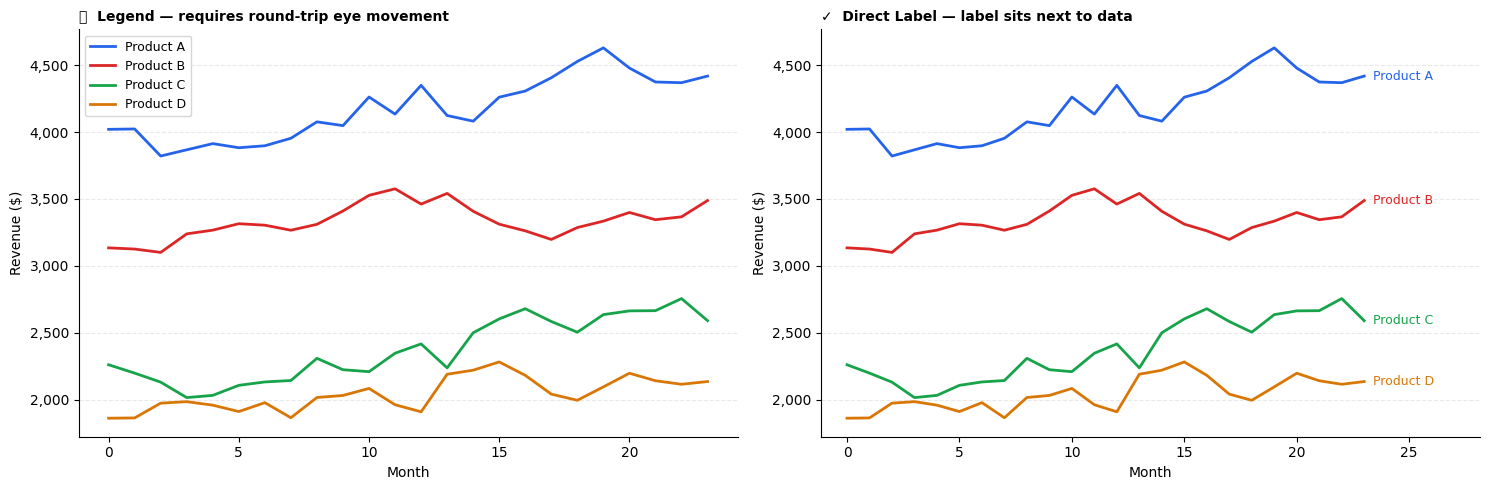

In [3]:
colors = categorical_colors(4)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Legend (bad)
ax = axes[0]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0, label=name)
ax.legend(frameon=True, fontsize=9, loc='upper left')
ax.set_title('❌  Legend — requires round-trip eye movement',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

# Panel 2: Direct label (good)
ax = axes[1]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0)
    label_last_point(ax, months, y, text=name, color=c,
                     fontsize=9, offset_x=6)
ax.set_title('✓  Direct Label — label sits next to data',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
# Expand x-axis to make room for labels
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] + 4)
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 2. Inline Series Labels

**Inline label** đặt nhãn ngay trên đường tại một vị trí x cho trước —
thay vì chỉ ở điểm cuối.

Phù hợp khi:
- Series không kết thúc ở cùng thời điểm
- Muốn nhãn ở giữa chart (ví dụ: tại điểm phân kỳ)
- Chart dài và điểm cuối quá xa so với phần data chính

`inline_series_labels` interpolate y-value tại vị trí x cho trước và đặt nhãn tại đó.

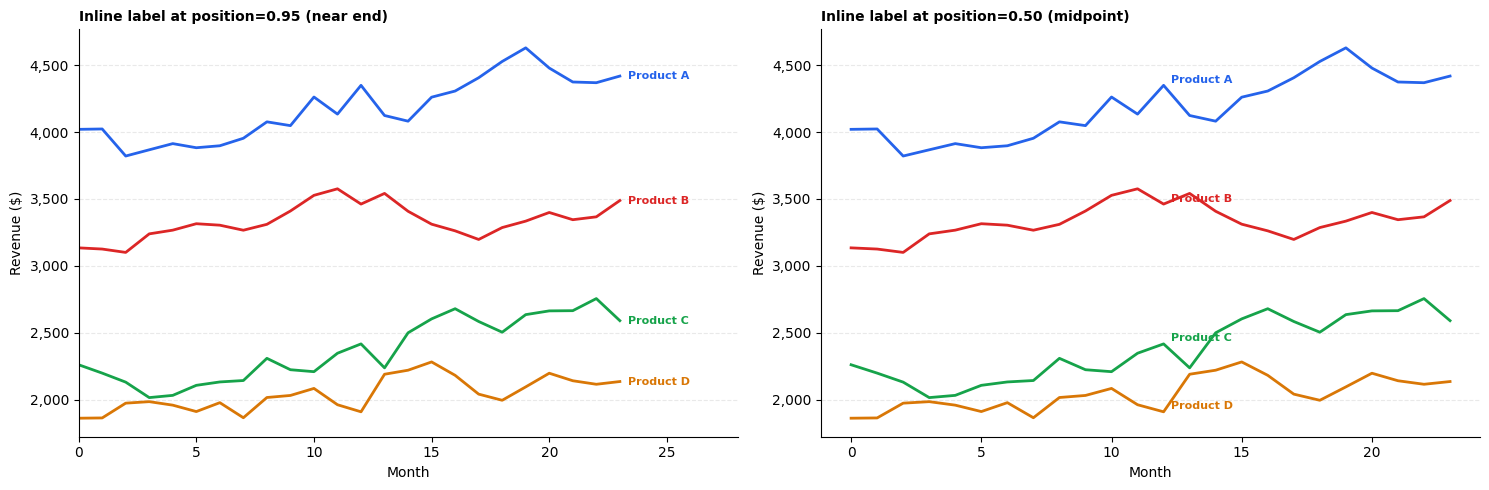

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

color_map = dict(zip(products.keys(), colors))

# Panel 1: label at end (position=1.0)
ax = axes[0]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0, label=name)
inline_series_labels(
    ax, months,
    series={k: v for k, v in products.items()},
    position=0.95,
    color_map=color_map,
    fontsize=8, offset=(6, 0),
)
ax.set_title('Inline label at position=0.95 (near end)',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
ax.set_xlim(months[0], months[-1] + 5)
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

# Panel 2: label at divergence point (position=0.5)
ax = axes[1]
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0, label=name)
inline_series_labels(
    ax, months,
    series={k: v for k, v in products.items()},
    position=0.50,
    color_map=color_map,
    fontsize=8, offset=(5, 4),
)
ax.set_title('Inline label at position=0.50 (midpoint)',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 3. Label Max / Min — Đánh dấu điểm quan trọng

Thay vì buộc người xem tự tìm đỉnh và đáy,
`label_max` và `label_min` tự động:
1. Tìm vị trí max/min bằng `np.nanargmax` / `np.nanargmin`
2. Đặt label với format tùy chỉnh
3. Offset để không đè lên data point

Kết hợp với `highlight_points` để thêm marker tại đỉnh/đáy.

C:\Users\Duy\AppData\Local\Temp\ipykernel_13068\994499763.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


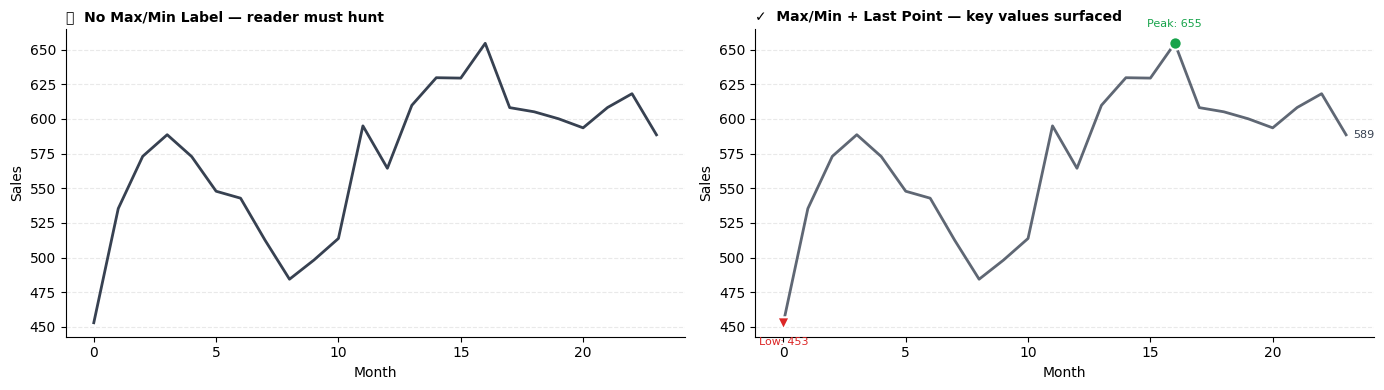

In [5]:
from vizint.perception import highlight_points

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: No labels — reader must hunt
ax = axes[0]
ax.plot(months, y_single, color='#374151', linewidth=2.0)
ax.set_title('❌  No Max/Min Label — reader must hunt',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Sales')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

# Panel 2: With max/min labels
ax = axes[1]
ax.plot(months, y_single, color='#374151', linewidth=2.0, alpha=0.8)

# Max
label_max(ax, months, y_single,
          fmt='Peak: {:,.0f}',
          color='#16A34A', fontsize=8, offset=(0, 10))
idx_max = int(np.nanargmax(y_single))
highlight_points(ax, [months[idx_max]], [y_single[idx_max]],
                 color='#16A34A', size=80, edgecolor='white')

# Min
label_min(ax, months, y_single,
          fmt='Low: {:,.0f}',
          color='#DC2626', fontsize=8, offset=(0, -10))
idx_min = int(np.nanargmin(y_single))
highlight_points(ax, [months[idx_min]], [y_single[idx_min]],
                 color='#DC2626', size=80, marker='v', edgecolor='white')

# Last point value
label_last_point(ax, months, y_single,
                 fmt='{:,.0f}', color='#374151', fontsize=8)

ax.set_title('✓  Max/Min + Last Point — key values surfaced',
             loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Sales')
format_thousands(ax, 'y')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 4. Declutter — Xóa Chart Junk

**Chart junk** (Edward Tufte) = mọi ink không encode data:
- Gridlines quá dày
- Tất cả 4 spines (viền)
- Tick marks không cần thiết
- Background color khác trắng
- 3D effects
- Drop shadows

Dưới đây so sánh cùng một chart với mức độ clutter khác nhau.

C:\Users\Duy\AppData\Local\Temp\ipykernel_13068\3326117323.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


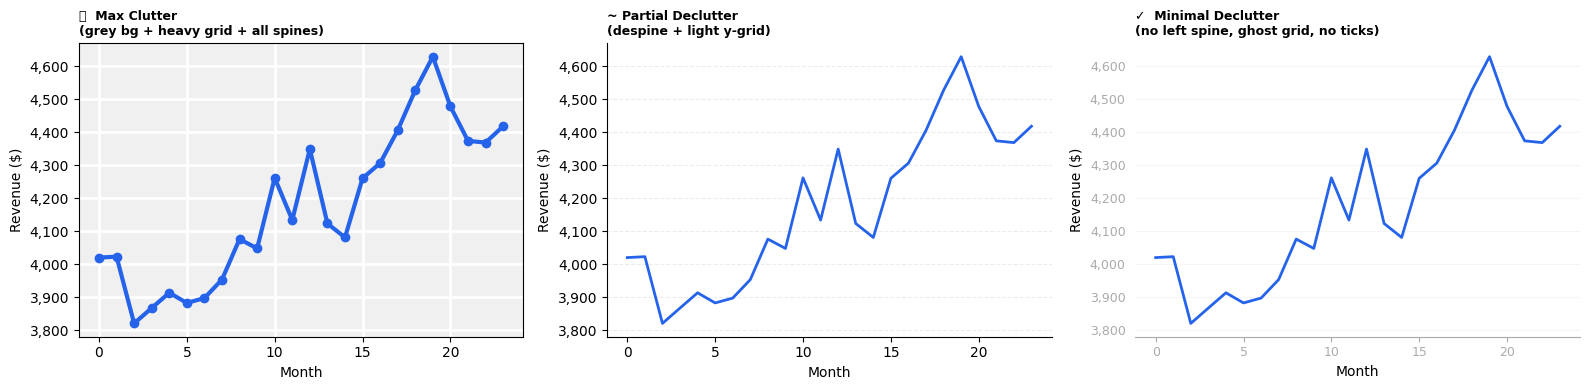

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white')

y_demo = list(products.values())[0]
c_demo = colors[0]

# Level 1: Maximum clutter
ax = axes[0]
ax.set_facecolor('#F0F0F0')
ax.grid(True, color='white', linewidth=2.0, which='both')
ax.plot(months, y_demo, color=c_demo, linewidth=3.0,
        marker='o', markersize=6)
ax.set_title('❌  Max Clutter\n(grey bg + heavy grid + all spines)',
             loc='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
# Deliberately keep all spines

# Level 2: Partial declutter
ax = axes[1]
ax.plot(months, y_demo, color=c_demo, linewidth=2.0)
despine(ax)             # remove top + right
set_grid(ax, which='y', color='#e0e0e0', linewidth=0.8, alpha=0.6)
ax.set_title('~ Partial Declutter\n(despine + light y-grid)',
             loc='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')

# Level 3: Minimal
ax = axes[2]
ax.plot(months, y_demo, color=c_demo, linewidth=2.0)
despine(ax, left=True)  # remove top + right + left
ax.yaxis.grid(True, color='#e8e8e8', linewidth=0.6, linestyle='-', alpha=0.5)
ax.set_axisbelow(True)
ax.tick_params(left=False)  # remove y tick marks
ax.set_title('✓  Minimal Declutter\n(no left spine, ghost grid, no ticks)',
             loc='left', fontsize=9, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
format_thousands(ax, 'y')
set_tick_style(ax, color='#aaaaaa', labelsize=9)

plt.tight_layout()
plt.show()

---
## 5. Number Formatting

Tick labels không được format tốt là một dạng cognitive load ẩn:
- `4200` → khó đọc hơn `4,200`
- `0.0652` → khó đọc hơn `6.5%`
- `1500000` → khó đọc hơn `1.5M`

`format_thousands` và `format_percent` áp dụng formatter ngay trên axis.
Cũng demo cách viết custom formatter với `FuncFormatter`.

C:\Users\Duy\AppData\Local\Temp\ipykernel_13068\1063491325.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


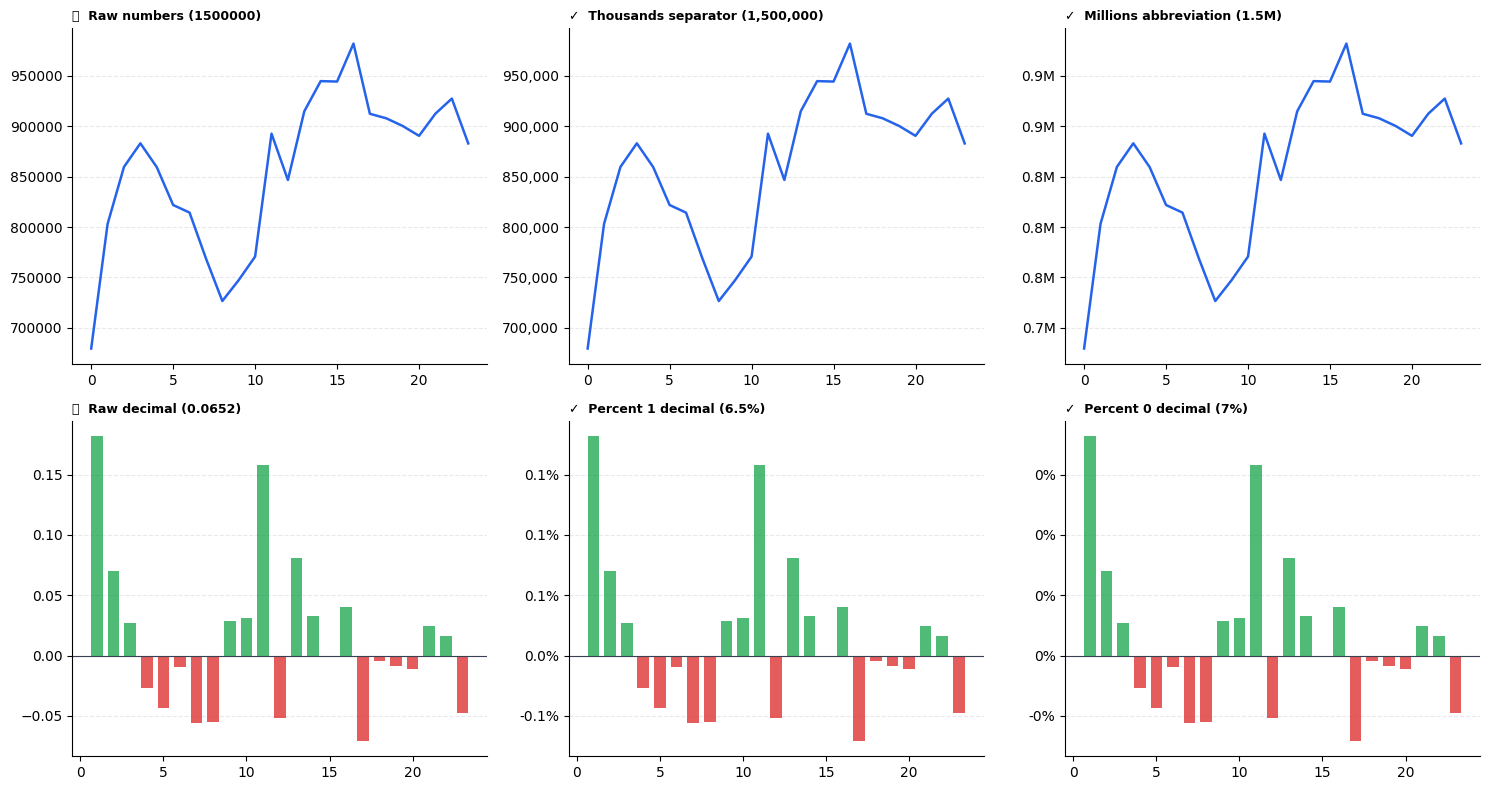

In [7]:
# Data có giá trị lớn và percentage
y_millions = y_single * 1500   # scale to millions
y_pct      = y_single / y_single.max()  # normalize to [0,1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='white')

# Row 1: Large numbers
titles_top = [
    '❌  Raw numbers (1500000)',
    '✓  Thousands separator (1,500,000)',
    '✓  Millions abbreviation (1.5M)',
]
for ax, title in zip(axes[0], titles_top):
    ax.plot(months, y_millions, color='#2563EB', linewidth=1.8)
    ax.set_title(title, loc='left', fontsize=9, fontweight='bold')
    despine(ax); set_grid(ax)

# Apply formatters
# axes[0][0]: no formatter (raw)
# axes[0][1]: thousands
format_thousands(axes[0][1], 'y')
# axes[0][2]: millions custom
axes[0][2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

# Row 2: Percentages
y_growth = np.diff(y_single) / y_single[:-1]  # month-over-month growth
months_diff = months[1:]

titles_bot = [
    '❌  Raw decimal (0.0652)',
    '✓  Percent 1 decimal (6.5%)',
    '✓  Percent 0 decimal (7%)',
]
for ax, title in zip(axes[1], titles_bot):
    ax.bar(months_diff, y_growth,
           color=['#16A34A' if v >= 0 else '#DC2626' for v in y_growth],
           alpha=0.75, width=0.7)
    ax.axhline(0, color='#374151', linewidth=0.8)
    ax.set_title(title, loc='left', fontsize=9, fontweight='bold')
    despine(ax); set_grid(ax)

# axes[1][0]: raw decimal
# axes[1][1]: 1 decimal percent
format_percent(axes[1][1], 'y', decimals=1)
# axes[1][2]: 0 decimal percent
format_percent(axes[1][2], 'y', decimals=0)

plt.tight_layout()
plt.show()

---
## 6. Typography Hierarchy

Typography tốt tạo ra **reading order** tự nhiên:
người xem đọc title trước → subtitle → axis label → annotation → caption.

vizint typography scale:

| Element | Size | Weight | Color |
|---------|------|--------|-------|
| Title | 16 | bold | #1a1a1a |
| Subtitle | 12 | normal | #555555 |
| Axis label | 11 | normal | #444444 |
| Tick label | 10 | normal | #888888 |
| Annotation | 9 | normal | #1a1a1a |
| Caption | 8 | normal | #888888 |
| Source | 8 | normal | #9CA3AF |

vizint Typography Scale:
  Title      : 16pt bold
  Subtitle   : 12pt normal
  Axis label : 11pt normal
  Tick       : 10pt normal
  Annotation : 9pt normal
  Caption    : 8pt normal


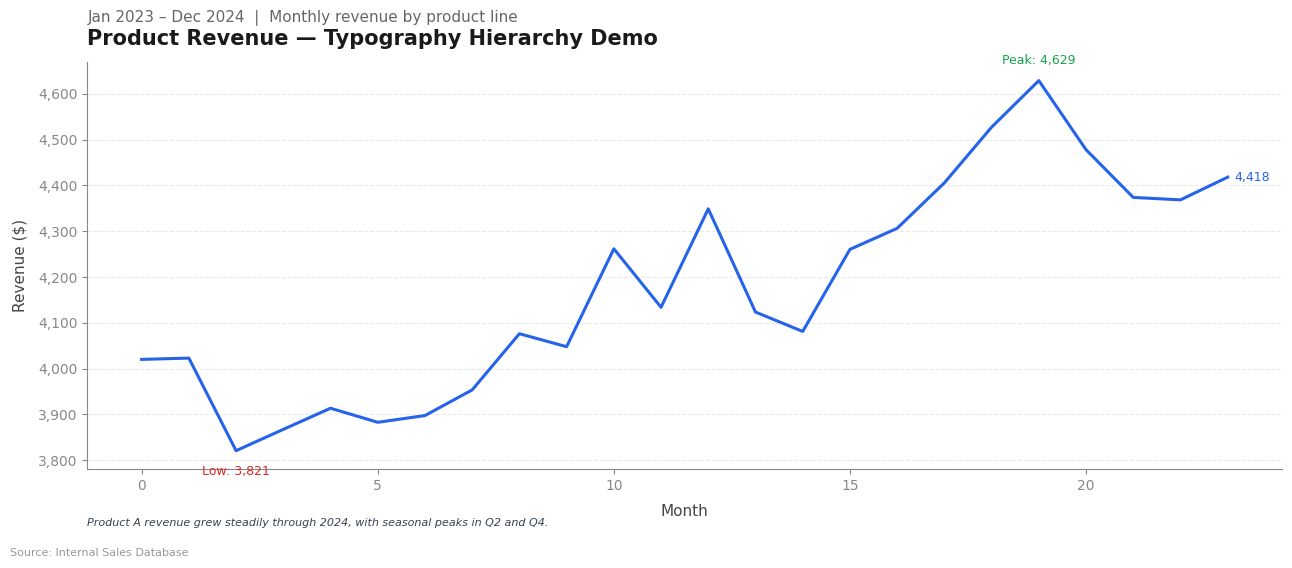

In [8]:
from vizint.annotation.notes import add_source_note

print('vizint Typography Scale:')
print(f'  Title      : {TITLE_SIZE}pt bold')
print(f'  Subtitle   : {SUBTITLE_SIZE}pt normal')
print(f'  Axis label : {AXIS_LABEL_SIZE}pt normal')
print(f'  Tick       : {TICK_SIZE}pt normal')
print(f'  Annotation : {ANNOTATION_SIZE}pt normal')
print(f'  Caption    : {CAPTION_SIZE}pt normal')

chart = (
    ChartBuilder(figsize=(13, 5.5))
    .set_title('Product Revenue — Typography Hierarchy Demo')
    .set_subtitle('Jan 2023 – Dec 2024  |  Monthly revenue by product line')
    .set_source('Internal Sales Database')
    .build()
)
ax = chart.ax

y_a = list(products.values())[0]
ax.plot(months, y_a, color='#2563EB', linewidth=2.2)

# Label max with ANNOTATION_SIZE
label_max(ax, months, y_a, fmt='Peak: {:,.0f}',
          color='#16A34A', fontsize=ANNOTATION_SIZE)
label_min(ax, months, y_a, fmt='Low: {:,.0f}',
          color='#DC2626', fontsize=ANNOTATION_SIZE)
label_last_point(ax, months, y_a, fmt='{:,.0f}',
                 color='#2563EB', fontsize=ANNOTATION_SIZE)

# Caption
add_caption(
    ax,
    'Product A revenue grew steadily through 2024, '
    'with seasonal peaks in Q2 and Q4.',
    fontsize=CAPTION_SIZE,
)

# Axis labels
set_axis_labels(ax, xlabel='Month', ylabel='Revenue ($)',
                fontsize=AXIS_LABEL_SIZE)
format_thousands(ax, 'y')
set_tick_style(ax, color='#888888', labelsize=TICK_SIZE)

plt.tight_layout()
plt.show()

---
## 7. Theme System

vizint có 4 built-in themes — mỗi theme tối ưu cho một ngữ cảnh khác nhau:

| Theme | Dùng cho |
|-------|----------|
| `clean` | Presentation, dashboard — white bg, light grid |
| `minimal` | Print, report — rất ít decoration |
| `research` | Academic paper — slightly off-white, heavier grid |
| `dark` | Dark mode dashboard, screen display |

- `apply_theme(ax, theme)` — áp dụng cho một axes cụ thể
- `set_global_theme(theme)` — áp dụng cho toàn bộ session (rcParams)

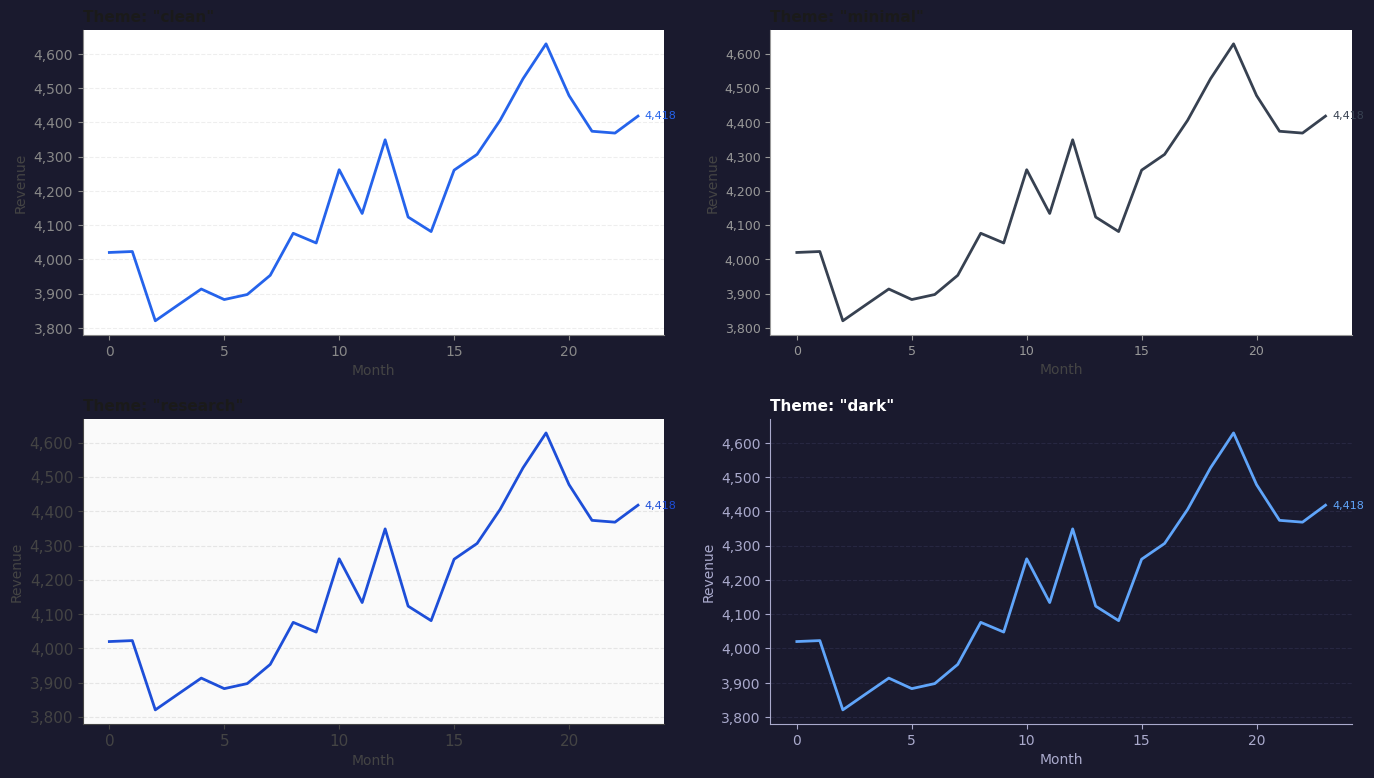

In [9]:
themes = ['clean', 'minimal', 'research', 'dark']
theme_colors = {
    'clean':    '#2563EB',
    'minimal':  '#374151',
    'research': '#1D4ED8',
    'dark':     '#60A5FA',
}
bg_colors = {
    'clean':    'white',
    'minimal':  'white',
    'research': '#fafafa',
    'dark':     '#1a1a2e',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.patch.set_facecolor('#f0f0f0')

y_demo = list(products.values())[0]

for ax, theme in zip(axes.flatten(), themes):
    ax.set_facecolor(bg_colors[theme])
    ax.plot(months, y_demo, color=theme_colors[theme],
            linewidth=2.0)
    label_last_point(ax, months, y_demo,
                     fmt='{:,.0f}', color=theme_colors[theme], fontsize=8)
    apply_theme(ax, theme)
    ax.set_title(f'Theme: "{theme}"',
                 loc='left', fontsize=11, fontweight='bold',
                 color='white' if theme == 'dark' else '#1a1a1a')
    ax.set_xlabel('Month',
                  color='#aaaacc' if theme == 'dark' else '#444444')
    ax.set_ylabel('Revenue',
                  color='#aaaacc' if theme == 'dark' else '#444444')
    format_thousands(ax, 'y')

plt.tight_layout(pad=1.5)
plt.show()

---
## 8. Data-Ink Ratio (Tufte)

**Edward Tufte** đề xuất nguyên tắc **Data-Ink Ratio**:

```
Data-Ink Ratio = Data ink / Total ink used
```

Maximize data-ink ratio = mọi ink trên chart phải encode data.
Ink không encode data = chart junk, nên xóa đi.

Dưới đây demo cùng data với ratio từ thấp → cao.

C:\Users\Duy\AppData\Local\Temp\ipykernel_13068\3398008584.py:51: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()


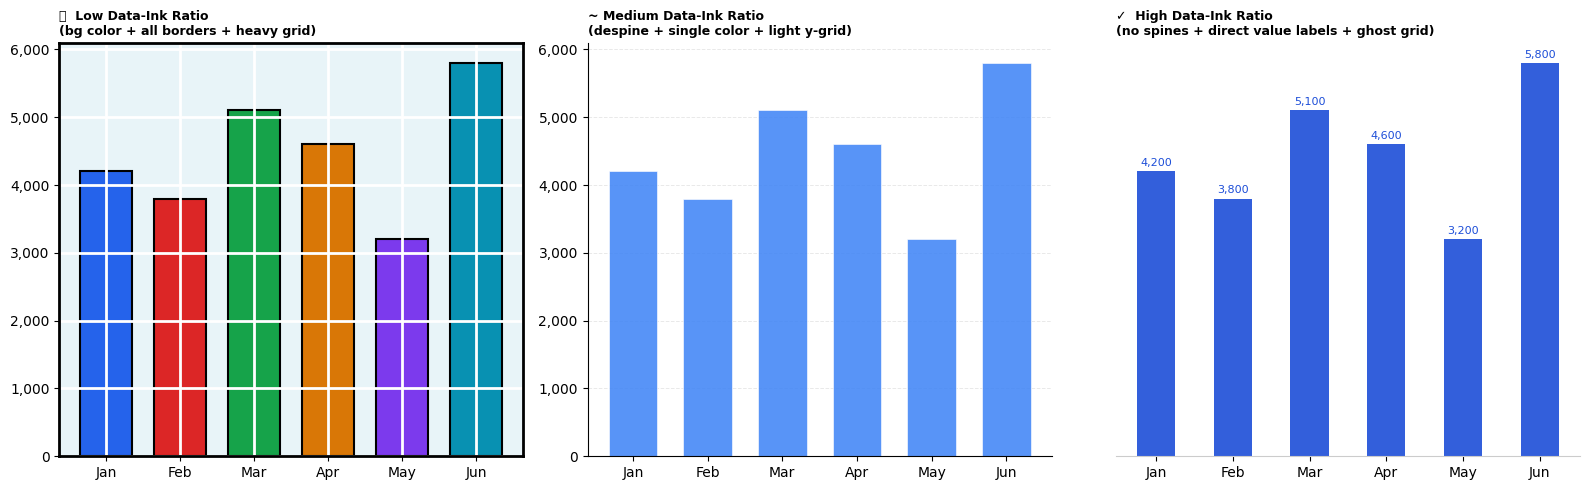

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='white')

y_bar = np.array([4200, 3800, 5100, 4600, 3200, 5800])
cats  = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
bar_colors = categorical_colors(6)

# Low ratio: every junk element
ax = axes[0]
ax.set_facecolor('#E8F4F8')
bars = ax.bar(cats, y_bar, color=bar_colors, edgecolor='black',
              linewidth=1.5, width=0.7)
# Heavy gridlines both axes
ax.grid(True, axis='both', color='white', linewidth=2.0)
# All spines visible with thick border
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_visible(True)
ax.set_title('❌  Low Data-Ink Ratio\n(bg color + all borders + heavy grid)',
             loc='left', fontsize=9, fontweight='bold')
format_thousands(ax, 'y')

# Medium ratio
ax = axes[1]
ax.bar(cats, y_bar, color='#3B82F6', edgecolor='white',
       linewidth=0.5, width=0.65, alpha=0.85)
despine(ax)
set_grid(ax, which='y', color='#e0e0e0', linewidth=0.7)
ax.set_title('~ Medium Data-Ink Ratio\n(despine + single color + light y-grid)',
             loc='left', fontsize=9, fontweight='bold')
format_thousands(ax, 'y')

# High ratio: Tufte-style
ax = axes[2]
ax.bar(cats, y_bar, color='#1D4ED8', edgecolor='none',
       width=0.5, alpha=0.9)
# Only baseline
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(left=False)
ax.yaxis.grid(True, color='#f0f0f0', linewidth=0.5)
ax.set_axisbelow(True)
# Value labels directly on bars
for i, (cat, val) in enumerate(zip(cats, y_bar)):
    ax.text(i, val + 80, f'{val:,}', ha='center', fontsize=8, color='#1D4ED8')
ax.set_yticks([])  # remove y ticks entirely — values are on bars
ax.set_title('✓  High Data-Ink Ratio\n(no spines + direct value labels + ghost grid)',
             loc='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. Before / After Chart Makeover

Áp dụng tất cả kỹ thuật đã học vào một makeover hoàn chỉnh.

**Checklist makeover:**
- [ ] Xóa legend → direct label
- [ ] Remove top/right spines
- [ ] Light grid (y-only)
- [ ] Format tick numbers
- [ ] Consistent font sizes
- [ ] Left-align title
- [ ] Add subtitle
- [ ] Add caption / takeaway
- [ ] Label max/min
- [ ] Add source note

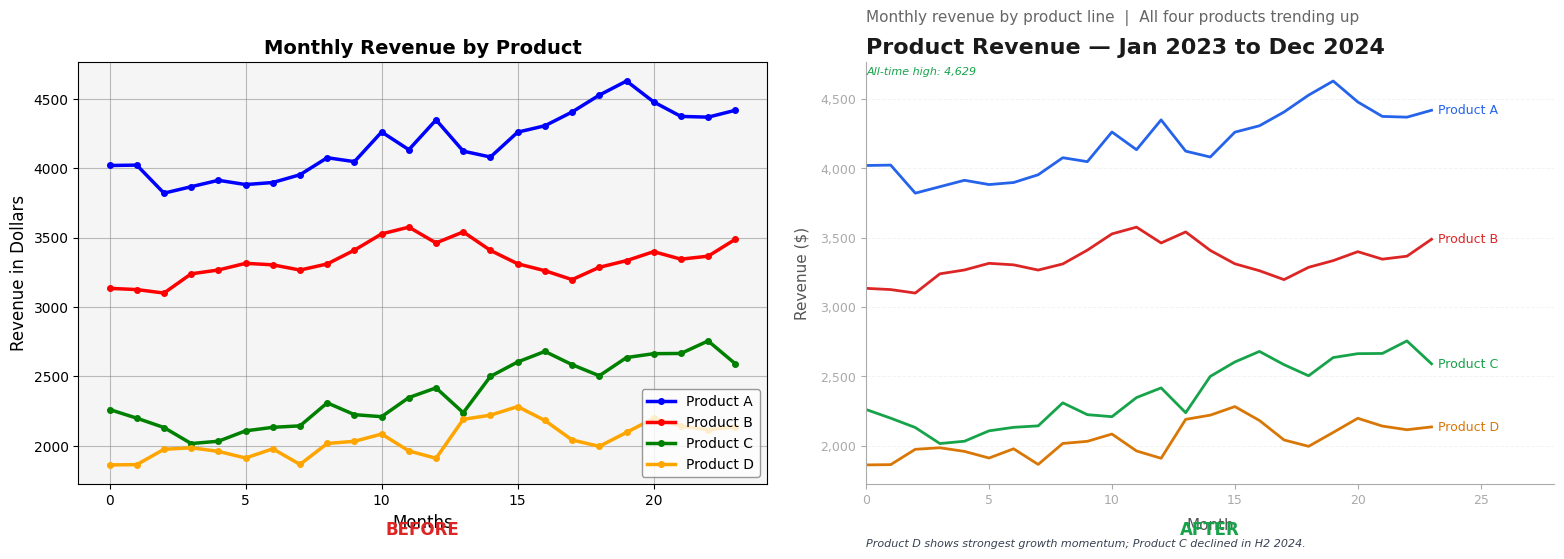

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# ── BEFORE ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#F5F5F5')

for (name, y), c in zip(products.items(), ['blue','red','green','orange']):
    ax.plot(months, y, color=c, linewidth=2.5,
            marker='o', markersize=4, label=name)

ax.legend(loc='lower right', frameon=True, fontsize=10,
          facecolor='white', edgecolor='grey')
ax.set_title('Monthly Revenue by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Months', fontsize=12)
ax.set_ylabel('Revenue in Dollars', fontsize=12)
ax.grid(True, color='grey', alpha=0.5)
ax.text(0.5, -0.12, 'BEFORE',
        transform=ax.transAxes, ha='center', fontsize=12,
        fontweight='bold', color='#DC2626')

# ── AFTER ─────────────────────────────────────────────────────────────────
ax = axes[1]

# Plot with proper colors
for (name, y), c in zip(products.items(), colors):
    ax.plot(months, y, color=c, linewidth=2.0)
    label_last_point(ax, months, y, text=name, color=c, fontsize=9, offset_x=5)

# Highlight overall max
all_y = np.concatenate(list(products.values()))
global_max = all_y.max()
ax.annotate(f'All-time high: {global_max:,.0f}',
            xy=(0, 0.97), xycoords='axes fraction',
            fontsize=8, color='#16A34A', style='italic')

# Clean styling
despine(ax)
set_grid(ax, which='y', color='#eeeeee', linewidth=0.7)
format_thousands(ax, 'y')
set_tick_style(ax, color='#aaaaaa', labelsize=9)
set_axis_labels(ax, xlabel='Month', ylabel='Revenue ($)',
                fontsize=AXIS_LABEL_SIZE, color='#555555')

# Expand x for labels
ax.set_xlim(months[0], months[-1] + 5)

# Title + subtitle via ChartBuilder style
ax.set_title('Product Revenue — Jan 2023 to Dec 2024',
             loc='left', fontsize=TITLE_SIZE, fontweight='bold', color='#1a1a1a')
ax.annotate('Monthly revenue by product line  |  All four products trending up',
            xy=(0, 1), xycoords='axes fraction',
            xytext=(0, 26), textcoords='offset points',
            fontsize=SUBTITLE_SIZE - 1, color='#666666', va='bottom')

add_caption(ax,
    'Product D shows strongest growth momentum; Product C declined in H2 2024.',
    y=-0.13, fontsize=CAPTION_SIZE,
)

ax.text(0.5, -0.12, 'AFTER',
        transform=ax.transAxes, ha='center', fontsize=12,
        fontweight='bold', color='#16A34A')

plt.tight_layout(pad=2.0)
plt.show()

---
## Summary — Cognitive Load Reduction Checklist

| Action | Function / Method | Cognitive Benefit |
|--------|------------------|------------------|
| Xóa legend | `label_last_point` | Loại bỏ round-trip eye movement |
| Inline label | `inline_series_labels` | Label gần data |
| Label max/min | `label_max`, `label_min` | Surface key values tự động |
| Remove spines | `despine(ax)` | Giảm visual noise |
| Light grid | `set_grid(ax, color='#eee')` | Grid hỗ trợ, không lấn át |
| Format numbers | `format_thousands`, `format_percent` | Đọc nhanh hơn |
| Font hierarchy | `TITLE_SIZE`, `CAPTION_SIZE`, ... | Reading order tự nhiên |
| Theme | `apply_theme(ax, 'clean')` | Consistent base styling |
| High data-ink | Remove markers, bg, borders | Chỉ giữ lại ink encode data |
| Caption | `add_caption` | Takeaway không cần suy luận |

---

### Key Takeaway

> Cognitive load reduction không phải là làm chart đơn giản hơn.
> Nó là **bỏ đi mọi thứ không encode thông tin** để
> mọi ink còn lại đều có lý do tồn tại.
>
> Chart tốt nhất là chart mà người xem hiểu được insight
> **trước khi họ kịp nhận ra rằng họ đang đọc một chart**.

**Next →** `06_process_and_journey.ipynb` — Khi data là một quy trình: waterfall, contribution, và decomposition.